# Early replication nucleosome entropy 

Recreate and clean up the story around gene body nucleosome entropy and replication timing



In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

outdir = "output/deconvolve_genome_g0066_10k_10x10_2024_09_20"
analysis = GenomeDeconvolutionAnalysis(outdir)


In [3]:
from src.geneset import get_deconvolved_geneset

genes = get_deconvolved_geneset()


In [65]:
all_f, all_gb_occ = analysis.load_stacked_mnase_data_for_genes(genes, 
    compute_gb_occ=True, padding=5000, normalize=False)


Failed to find center key for:  YHR055C
Failed to load 17 files


In [66]:
# Load replication timing

# Sort the gb occ by replication timing, also compute entropy and compare the stories

# Then plot centered on the replication timing, reuse code previously written
# for centering

In [67]:
genes_replication = pd.read_csv('data/replication_timing/yl_2019/genes_replication_timing_shared.csv').set_index('orf_name')
genes_replication = genes_replication.sort_values('replication_time')

In [68]:
genes_replication

,replication_time,replication_H_index
orf_name,,
YGR194C,4.3477,105.0
YGR195W,4.3477,105.0
YJL116C,4.3477,105.0
YJL115W,4.3477,105.0
YDR046C,4.9289,106.0
...,...,...
YDR252W,15.9710,125.0
YCR086W,17.1333,127.0
YCR087C-A,17.1333,127.0


In [69]:
from src.config import load_configs_by_config_type

config, _ = load_configs_by_config_type('shared')
t_indices = config.get_Hpositions_for_branch('t')

In [70]:
all_gb_occ_sorted_by_repl = all_gb_occ.loc[genes_replication.index].dropna()

In [71]:
normalized_gb_occ = (all_gb_occ_sorted_by_repl - 
                     all_gb_occ_sorted_by_repl.mean(axis=1).values.reshape(-1, 1))/\
                     all_gb_occ_sorted_by_repl.std(axis=1).values.reshape(-1, 1)

Text(0.5, 0.98, 'Nucleosome Entropy sorted by replication timing')

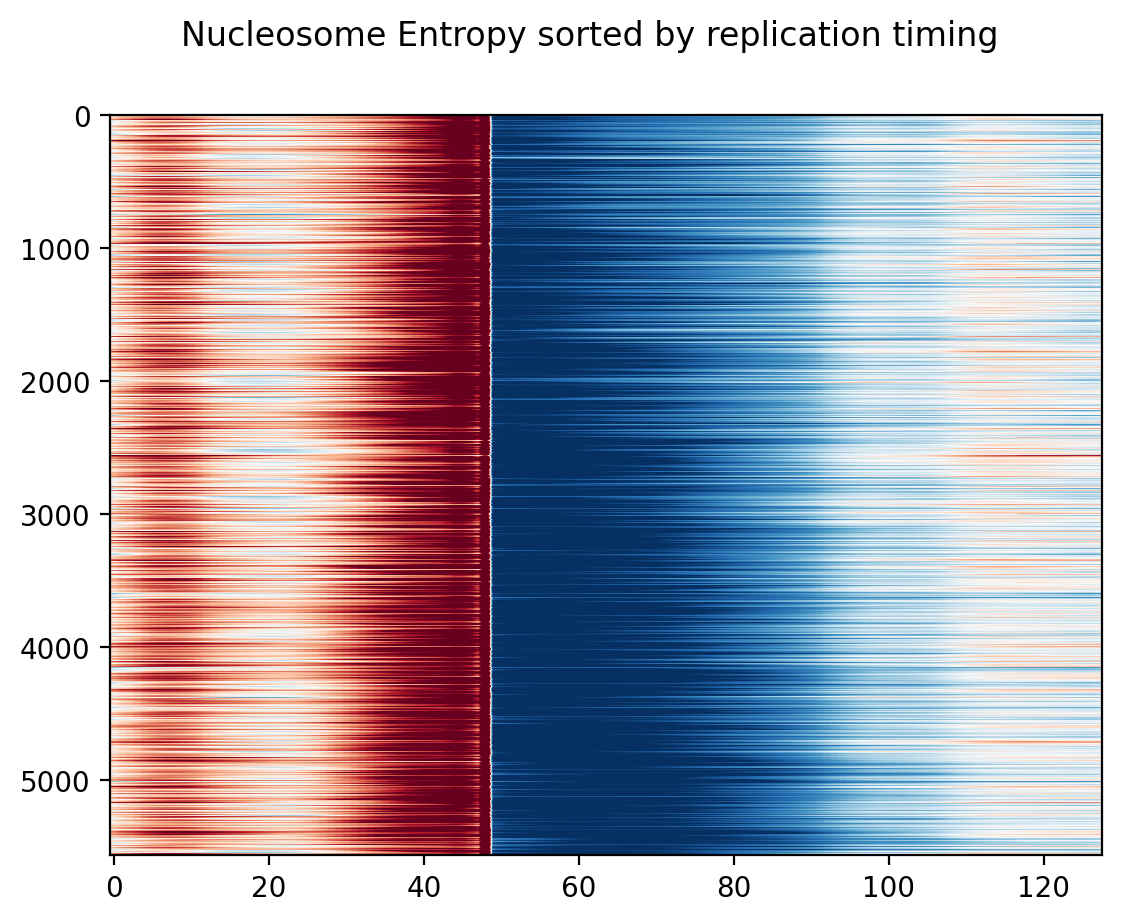

In [75]:
plt.imshow(normalized_gb_occ[t_indices].astype(float), aspect='auto', vmin=-1, vmax=1,
           cmap='RdBu_r')
plt.suptitle("Nucleosome Entropy sorted by replication timing")

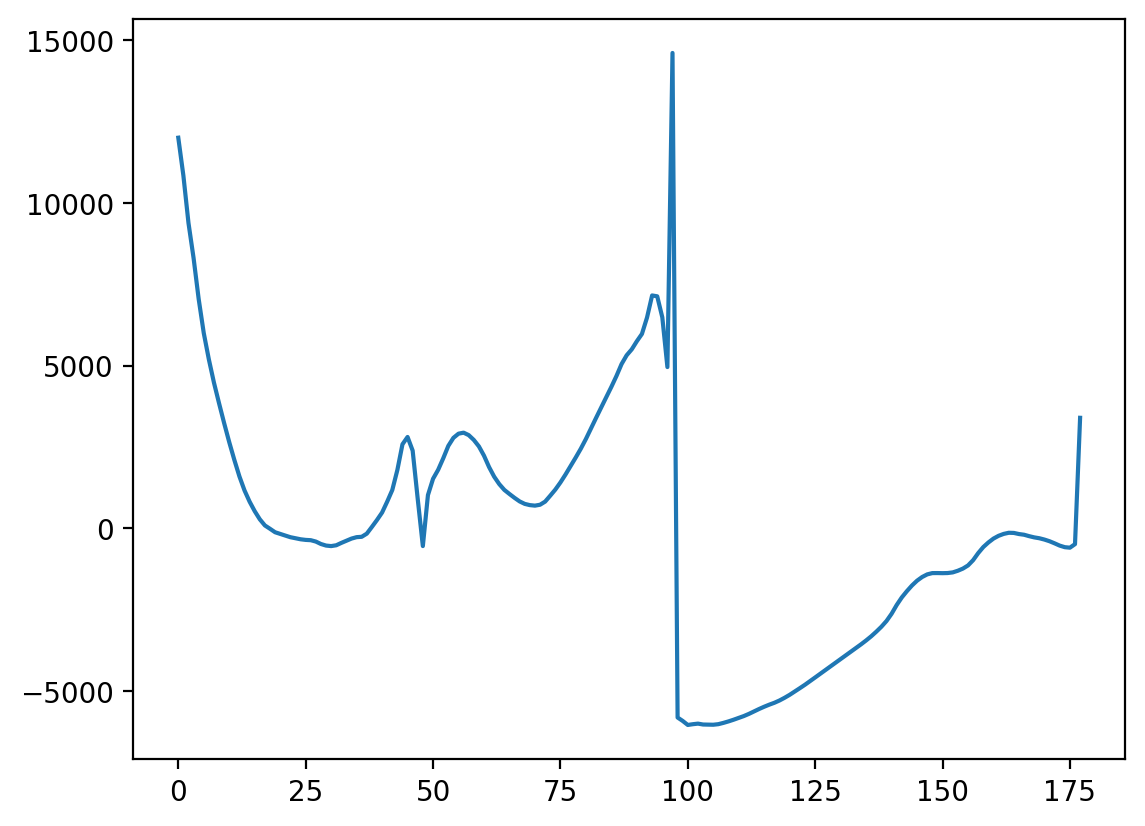

In [79]:
plt.plot(normalized_gb_occ.sum(axis=0))

In [81]:
from src.GenomeDeconvolution import GenomeDeconvolution
# Alternatively, compute the nucleosome entropy for each gene then deconvolve these values

genome_deconvolution = GenomeDeconvolution(save_dir=None)


In [95]:
rep1_plus_ones = pd.read_csv('datasets/computed_mnase/rep1_plus_ones.csv').set_index('orf_name')
rep2_plus_ones = pd.read_csv('datasets/computed_mnase/rep2_plus_ones.csv').set_index('orf_name')

rep1_plus_ones = rep1_plus_ones.join(genes, how='inner')
rep2_plus_ones = rep2_plus_ones.join(genes, how='inner')

In [97]:
rep1_plus_ones

,+1,gene,chr,cat,start,stop,strand,classification,length,TSS,PAS,manually_curated,promoter_start,promoter_end,gene_body_start,gene_body_end
orf_name,,,,,,,,,,,,,,,,
YAL067W-A,2392.0,YAL067W-A,1,gene,2480,2707,+,Uncharacterized,227,2480,2707,NaN,2180.0,2480.0,2480.0,2980.0
YAL067C,9041.0,SEO1,1,gene,7235,9016,-,Verified,1781,9016,7235,NaN,9016.0,9316.0,8516.0,9016.0
YAL064C-A,13683.0,YAL064C-A,1,gene,13363,13743,-,Uncharacterized,380,13743,13363,NaN,13743.0,14043.0,13243.0,13743.0
YAL064W,21535.0,YAL064W,1,gene,21566,21850,+,Verified,284,21566,21850,NaN,21266.0,21566.0,21566.0,22066.0
YAL063C-A,22737.0,YAL063C-A,1,gene,22395,22685,-,Uncharacterized,290,22685,22395,NaN,22685.0,22985.0,22185.0,22685.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YPR198W,934043.0,SGE1,16,gene,934034,935665,+,Verified,1631,933984,935759,False,933684.0,933984.0,933984.0,934484.0
YPR199C,939001.0,ARR1,16,gene,938148,939032,-,Verified,884,939059,937970,False,939059.0,939359.0,938559.0,939059.0
YPR200C,939715.0,ARR2,16,gene,939279,939671,-,Verified,392,939779,939195,False,939779.0,940079.0,939279.0,939779.0


In [103]:

gene = rep1_plus_ones.iloc[0]
p1 = gene['+1']
mnase_span =  p1, p1+500
chrom = gene.chr


In [105]:
genome_deconvolution.load_chrom_span(chrom, mnase_span, downsample=False)

Already loaded chromosome reads for 1. Using cache.
Applying a normalization for length distribution


KeyError: 2392.0

In [ ]:
genome_deconvolution